### 引言

在学习“人工智能”之前，我想通过编写一个线性拟合程序来复习python中向量、拟合、预测等定义的概念。

线性回归是要拟合出如下的一条曲线：

$$
{y} = {K}{x}+{b},
$$

其中的y，x，b是向量，而K是矩阵。

线性回归也可以理解为一个单层神经网络，如下图所示：

![单层线性神经网络.png](./PPT-figure/单层线性神经网络.png)

该图只显示连接模式，即只显示每个输入如何连接到输出，隐去了权重和偏置的值。

### 算法实现

可以参考[线性回归的从零开始实现](https://zh.d2l.ai/chapter_linear-networks/index.html)文档编码。
需要使用的库：
```text
numpy
matplotlib
sklearn
```
编码实现一个房价预测线性回归模型的训练和验证，输入为2维：面积、层数，输出维1维：房价。

In [56]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam

In [9]:
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'Version: {torch.__version__}')

CUDA Available: True
Version: 2.11.0+cu130


In [74]:
# ==========================================
# 1. 数据准备 (模拟双特征数据)
# ==========================================
# 设置随机种子，保证结果可复现
torch.manual_seed(42)

# 生成 1000 个样本
n_samples = 100

# 特征1：面积 (50-150平米)
area = 50 + 100 * torch.rand(n_samples, 1)

# 特征2：房龄 (0-20年)
age = 20 * torch.rand(n_samples, 1)

# 将两个特征拼接到一起，形成 [100, 2] 的矩阵
# dim=0竖着拼接; dim=1横着拼接
X = torch.cat((area, age), dim=1)
print(X.shape) # 100：100个样本；2：2个输入维度

torch.Size([100, 2])


In [75]:
# 生成标签 y (房价)
# 假设真实规律：房价 = 3 * 面积 - 2 * 房龄 + 10 (基础价) + 噪声
# 注意：这里面积系数是正的，房龄系数是负的（越老越便宜）
true_w = torch.tensor([[3.0], [-2.0]]) 
true_b = torch.tensor([10.0])
y = X @ true_w + true_b + torch.randn(n_samples, 1) * 5  # @ 表示矩阵乘法
print(true_w)


tensor([[ 3.],
        [-2.]])


In [76]:
# ==========================================
# 2. 定义模型 (深度学习写法)
# ==========================================
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # 定义网络层：输入维度是2，输出维度是1
        # 这对应数学公式：y = w1*x1 + w2*x2 + b
        self.linear = nn.Linear(2, 1) # 2代表输入维度，1代表输出维度

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

In [77]:
# ==========================================
# 3. 定义损失函数与优化器
# ==========================================
criterion = nn.MSELoss() # 均方误差损失
optimizer = Adam(model.parameters(), lr=0.0001) 

In [78]:
# ==========================================
# 4. 训练循环
# ==========================================
num_epochs = 100000
for epoch in range(num_epochs):
    # 1. 前向传播：把数据喂给模型
    y_pred = model(X)
    
    # 2. 计算损失：看看预测值和真实值差多少
    loss = criterion(y_pred, y)
    
    # 3. 反向传播与更新：这是深度学习的核心
    optimizer.zero_grad() # 清空旧梯度
    loss.backward()       # 计算新梯度
    optimizer.step()      # 更新权重 w 和偏置 b

    if (epoch + 1) % 10000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10000/100000], Loss: 20789.5547
Epoch [20000/100000], Loss: 2362.1973
Epoch [30000/100000], Loss: 542.0931
Epoch [40000/100000], Loss: 314.8338
Epoch [50000/100000], Loss: 155.0828
Epoch [60000/100000], Loss: 60.5610
Epoch [70000/100000], Loss: 24.6441
Epoch [80000/100000], Loss: 22.1259
Epoch [90000/100000], Loss: 21.1178
Epoch [100000/100000], Loss: 20.2447


In [72]:
# ==========================================
# 5. 查看结果
# ==========================================
# 提取学习到的参数
# 可以看到在使用pytorch时，不需要去手动实例化/设计参数，pytorch会帮我们做好。
w_learned = model.linear.weight.data.numpy()
b_learned = model.linear.bias.data.numpy()

print(f"\n--- 训练结果 ---")
print(f"真实权重: [3.0, -2.0]")
print(f"学习到的权重: {w_learned.flatten()}") # 对应两个特征的系数
print(f"真实偏置: 10.0")
print(f"学习到的偏置: {b_learned}")


--- 训练结果 ---
真实权重: [3.0, -2.0]
学习到的权重: [ 3.0134318 -2.1548543]
真实偏置: 10.0
学习到的偏置: [10.035732]



--- 预测示例 ---
输入: 面积=100, 房龄=5
预测房价: 299.73


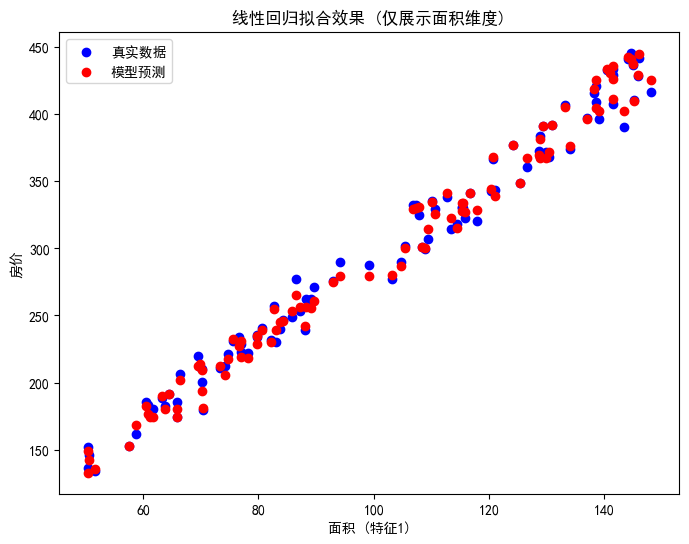

In [80]:
# ==========================================
# 6. 简单预测
# ==========================================
# 假设有一个新房子：面积100平米，房龄5年
X_new = torch.tensor([[100.0, 5.0]]) 
with torch.no_grad(): # 预测时不需要计算梯度
    pred_price = model(X_new)
    print(f"\n--- 预测示例 ---")
    print(f"输入: 面积=100, 房龄=5")
    print(f"预测房价: {pred_price.item():.2f}")

# 可视化（仅展示特征1与价格的关系，因为2维特征很难在2D平面画出完整超平面）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0].numpy(), y.numpy(), color='blue', label='真实数据')
plt.scatter(X[:, 0].numpy(), model(X).data.numpy(), color='red', label='模型预测')
plt.xlabel('面积 (特征1)')
plt.ylabel('房价')
plt.title('线性回归拟合效果 (仅展示面积维度)')
plt.legend()
plt.grid(False)
plt.show()